# POC 2B project (VGG16)

- Creation : *24/05/2025*

**Utilisation de ConvnetWrapperForDeconvolution et vérification de non régression avec cette méthode.**

Réalisation d'un tentative de reproduction de la Figure 2 de l'article :
1. [X] Chargement d'une version de ConvNet (AlexNet ou VGG*) adaptée pour la déconvolution
1. [X] Pour chaque couche cachée choisie dans la Figure 3 de l'article, sur (une sous-partie du)/le jeu de données
   - récupérer le top K des neurones choisis au hasard
   - récupérer le top K des activations maximums par couche, toutes cartes confondues
1. [X] Affichage sous forme de grille des déconvolutions et des champs réceptifs. Comparaison avec les images fournies en entrée.
1. [X] Calcul des déconvolutions des tops K, les champs réceptifs équivalents et les extraits des images en entrée correspondants

## Variables de contrôle

In [1]:
# Variables de contrôle d'éxécution du script
test_dataloader = True
test_image_one_by_one = False

# 0 : sortie de la première couche opératoire du modèle
# pour VGG16 - sortie de bloc de convolution correspondant à un MaxPool2d (sauf cas particulier)
# MaxPool2d_layer_idx = [4, 9, 16, 23, 30]

probed_layer_idx = [4, 9, 16, 23, 30] # couche cachées à surveiller
#probed_neuron_by_layer = [9, 16, 12, 10, 10] # neurones à surveiller dans chaque couche cachée
probed_neuron_by_layer = [9, 7, 5, 5, 5] # neurones à surveiller dans chaque couche cachée
K = 9 # Top K

SEED = 42 # Random seed for reproducibility

N_images = 2 # Number of images for image by image test
i_stop = 0 # Stop if i_stop > 0

## Modules

In [2]:
import os
import random
from typing import Tuple

import numpy as np
import torch
import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm, trange
from torchinfo import summary
from PIL import Image, ImageDraw

from datasets import imagenet_mean, imagenet_std, DATASET_2, DATASET_1, CustomImageDataset, get_label_data_from_filename
from utils.convnet_wrapper_for_deconvolution import ConvnetWrapperForDeconvolution
from utils.utils_cnn import get_output_sizes, get_receptive_field_in_pixel_space
from utils.utils_images import display_image_tensor as display_image_tensor_, to_0_255, unnormalize, display_images_list_grid, to_0_1, show_image_tensor, to_0_Vmax
from utils.topk import TopK
from utils.deconvolution import deconvolution
from utils.utils_rgb import display_rgb_distributions


In [3]:
model_name = "vgg16"
TORCHVISION_MODELS_WEIGHTS = torchvision.models.VGG16_Weights

In [4]:
random.seed(SEED)
#rng = np.random.default_rng()

#random_layer_count = rng.integers(len(model_deconv.convnet_features)+1)
#random_layer_idx = rng.choice(len(model_deconv.convnet_features), random_layer_count, replace=False)

In [5]:
# Spécifiquement pour un carnet de type Jupyter
def display_image_tensor(
        img_tensor, resize: Tuple[int, int] = None, resample: int = Image.Resampling.NEAREST, verbose=True
        ):
    if display:
        display_image_tensor_(img_tensor, resize=resize, resample=resample, verbose=verbose, fn_display=display)

## Devices

Détection du GPU disponible.

In [6]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"{device} est disponible")

mps est disponible


## Les données

Création du `dataset`et du `dataloader`.

In [7]:
#DATASET = DATASET_2 # le 1K images pour l'instant
DATASET = DATASET_1 # le 50K images

imagenet_mean = DATASET["means"]
imagenet_std = DATASET["stds"]

geo_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
])
"""
transforms = T.Compose([
    geo_transforms,
    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])
"""

transforms = TORCHVISION_MODELS_WEIGHTS.IMAGENET1K_V1.transforms()

get_label_data = lambda f: get_label_data_from_filename(f, DATASET["path"])
dataset_path = DATASET["mounted_path"] if os.path.exists(DATASET["mounted_path"]) else DATASET["path"]
print(f"Utilisation du dataset {DATASET['name']} situé dans {dataset_path}")

dataset = CustomImageDataset(
    dataset_path,
    transform=transforms,
    extension="JPEG",
    dataset_mode=True,
    only_label_idx=False, # On a besoin de l'index pour le nom du fichier
    get_label_data=get_label_data,
    )

batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Utilisation du dataset imagenet_val_images (50K images) situé dans /Users/me/Documents/Work/Dev/_data/imagenet_val_images


En mode test : vérification de la sortie du dataset et du dataloader

In [8]:
if test_dataloader:
    data = dataset[1]
    print(f"data: {data}")

data: (tensor([[[0.8789, 0.9132, 0.9474,  ..., 1.4954, 1.4612, 1.4612],
         [0.8961, 0.8789, 0.9303,  ..., 1.4612, 1.4612, 1.4954],
         [0.8961, 0.8789, 0.8618,  ..., 1.4612, 1.4954, 1.4783],
         ...,
         [1.4269, 1.3927, 1.3070,  ..., 1.8037, 1.7694, 1.7523],
         [1.4440, 1.5297, 1.4612,  ..., 1.8037, 1.8208, 1.7865],
         [1.4783, 1.5125, 1.4954,  ..., 1.7865, 1.7694, 1.7865]],

        [[1.2206, 1.1856, 1.1681,  ..., 1.7458, 1.7808, 1.8333],
         [1.2031, 1.1506, 1.1681,  ..., 1.7808, 1.8158, 1.7983],
         [1.2031, 1.1681, 1.2206,  ..., 1.8158, 1.7983, 1.7808],
         ...,
         [1.6933, 1.6758, 1.6408,  ..., 2.0434, 2.0784, 2.1134],
         [1.6933, 1.8158, 1.7633,  ..., 2.0784, 2.0959, 2.1310],
         [1.6758, 1.7108, 1.7108,  ..., 2.0959, 2.1134, 2.1310]],

        [[1.4897, 1.5071, 1.5420,  ..., 1.8731, 1.8905, 1.9254],
         [1.5071, 1.4897, 1.4897,  ..., 1.8905, 1.8905, 1.8731],
         [1.5071, 1.5071, 1.5420,  ..., 1.9080, 1.8

In [9]:
if test_dataloader:
    # Dans la configuration (dataset_mode=True, only_label_idx=False) => 
    #   [[image_trfm], [label_idx], [label_code], [idx]]
    i_element = 1
    batch = next(iter(dataloader))

    print("Type batch :", type(batch))
    print("Dimension batch:", len(batch), end="\n\n")
    
    print("Première partie du Batch :", batch[0].size())
    print("Deuxième partie du Batch :", batch[1].size())
    print("Troisième partie du Batch :", len(batch[2]))
    print("Quatrième partie du Batch :", batch[3].size(), end="\n\n")
    
    print("Image (taille du tenseur):", batch[0][i_element].size())
    print("Idx etiquette :", batch[1][i_element].item())
    print("Code etiquette :", batch[2][i_element])
    print("Id file :", batch[3][i_element].item())

Type batch : <class 'list'>
Dimension batch: 4

Première partie du Batch : torch.Size([32, 3, 224, 224])
Deuxième partie du Batch : torch.Size([32])
Troisième partie du Batch : 32
Quatrième partie du Batch : torch.Size([32])

Image (taille du tenseur): torch.Size([3, 224, 224])
Idx etiquette : 907
Code etiquette : n04591713
Id file : 46606


## Le modèle

In [10]:
model_convnet = torch.hub.load('pytorch/vision', model_name, weights=TORCHVISION_MODELS_WEIGHTS.IMAGENET1K_V1)
model_convnet.eval()
model_deconv = ConvnetWrapperForDeconvolution(model_convnet, model_convnet.features)

Using cache found in /Users/me/.cache/torch/hub/pytorch_vision_main


Résumé de la structure du modèle de type ConvNet

In [11]:
#print("> Résumé de la structure du modèle de type ConvNet")
print(model_convnet)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Tableau des dimensionnalités des couches cachées du modèle

In [12]:
# print("> Tableau des dimensionnalités des couches cachées du modèle")
batch_input = dataset[0][0].unsqueeze(dim=0)
print(batch_input.size())
model_deconv.set_return_switch_indices(False)
summary(model_convnet, input_size=batch_input.size(), mode="eval")

torch.Size([1, 3, 224, 224])


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

## Récupération des activations des neurones surveillés

Création des structures topK et choix aléatoire des coordonnées de $N$ neurones surveillés par couche cachée indiquée.

In [13]:
# Récupération des tailles des sorties afin de pouvoir choisir des coordonnées aléatoires
# dans les sorties des couches
input_size=batch_input.size()
model_deconv.set_return_switch_indices(False)
output_sizes = get_output_sizes(model_deconv.convnet_features, input_size=input_size, last_2d=False)
print("Dimensions des différentes couches cachées")
for layer_idx, output_size in enumerate(output_sizes):
    print(f"\tcouche {layer_idx:2d} : {output_size}")

topk_activations_by_neuron = {}
coord_activations = {}
for layer_idx, n_neurons in zip(probed_layer_idx, probed_neuron_by_layer):
    coord_activations[layer_idx] = []
    i = 0
    # Randomly select N coordinates in the output of the layer : chanel, row, col
    while i < n_neurons:
        # Choisir une coordonnée aléatoire dans la sortie de la couche
        #chn = rng.integers(output_sizes[layer_idx][0])
        #row = rng.integers(output_sizes[layer_idx][1])
        #col = rng.integers(output_sizes[layer_idx][2])
        chn = random.randint(0, output_sizes[layer_idx][0]-1)
        row = random.randint(0, output_sizes[layer_idx][1]-1)
        col = random.randint(0, output_sizes[layer_idx][2]-1)
        # Vérifier que la coordonnée n'est pas déjà choisie (on ne veut pas de doublons)
        if (chn, row, col) not in coord_activations[layer_idx]:
            coord_activations[layer_idx].append((chn, row, col))
            i += 1
    topk_activations_by_neuron[layer_idx] = {coord: TopK(K) for coord in coord_activations[layer_idx]}
print(f"Coordonnées choisies : {coord_activations}")

Dimensions des différentes couches cachées
	couche  0 : (64, 224, 224)
	couche  1 : (64, 224, 224)
	couche  2 : (64, 224, 224)
	couche  3 : (64, 224, 224)
	couche  4 : (64, 112, 112)
	couche  5 : (128, 112, 112)
	couche  6 : (128, 112, 112)
	couche  7 : (128, 112, 112)
	couche  8 : (128, 112, 112)
	couche  9 : (128, 56, 56)
	couche 10 : (256, 56, 56)
	couche 11 : (256, 56, 56)
	couche 12 : (256, 56, 56)
	couche 13 : (256, 56, 56)
	couche 14 : (256, 56, 56)
	couche 15 : (256, 56, 56)
	couche 16 : (256, 28, 28)
	couche 17 : (512, 28, 28)
	couche 18 : (512, 28, 28)
	couche 19 : (512, 28, 28)
	couche 20 : (512, 28, 28)
	couche 21 : (512, 28, 28)
	couche 22 : (512, 28, 28)
	couche 23 : (512, 14, 14)
	couche 24 : (512, 14, 14)
	couche 25 : (512, 14, 14)
	couche 26 : (512, 14, 14)
	couche 27 : (512, 14, 14)
	couche 28 : (512, 14, 14)
	couche 29 : (512, 14, 14)
	couche 30 : (512, 7, 7)
Coordonnées choisies : {4: [(14, 3, 94), (35, 31, 28), (17, 94, 13), (11, 75, 54), (4, 3, 11), (27, 29, 64), 

Générations des activations

### Test image par image

In [14]:
### TEST "image par image###
if test_image_one_by_one:
    dataset_test = CustomImageDataset(
        dataset_path,
        transform=transforms,
        extension="JPEG",
        dataset_mode=False,
        only_label_idx=False, # On a besoin de l'index pour le nom du fichier
        get_label_data=get_label_data,
        )

    model_deconv.to(device)
    all_activations = []
    for i in trange(0, N_images):
        image, image_trfm, label_idx, label_code, input_file_idx = dataset_test[i]
        batch_input = image_trfm.unsqueeze(dim=0).to(device)
        activations = model_deconv.get_activations(batch_input, coord_activations, verbose=True)
        all_activations.append((activations, torch.tensor([input_file_idx])))

    print(f"Toutes les activations : {all_activations}")

### Tout ou partie du jeu de données

In [15]:
if not test_image_one_by_one:
    BATCH_IMAGES_TRFM = 0
    #BATCH_LABEL_INDICES = 1
    BATCH_FILE_INDICES = 3

    if i_stop < 0:
        i_stop = min(len(dataloader) + i_stop, 1)
    total = min(i_stop, len(dataloader)) if i_stop else len(dataloader)

    model_deconv.to(device)
    all_activations = []
    i_batch = 0
    for batch in tqdm(dataloader, total=total, desc="Propagation", unit="batch"):
        if i_stop and i_batch >= i_stop:
            break
        batch_input = batch[BATCH_IMAGES_TRFM].to(device)
        #batch_label_idx = batch[BATCH_LABEL_INDICES]
        batch_input_file_idx = batch[BATCH_FILE_INDICES]

        # On fait passer le batch dans le modèle
        # et on récupère les activations des couches sélectionnées
        #with torch.no_grad():
        #    model_deconv.convnet_features_to_device(device)

        activations = model_deconv.get_activations(batch_input, coord_activations, verbose=False)
        all_activations.append((activations, batch_input_file_idx))

        i_batch += 1

Propagation:   0%|          | 0/1563 [00:00<?, ?batch/s]

Injection dans les topK

In [16]:
for activations, batch_input_file_idx in all_activations:
    for idx_layer, activations_layer in activations.items():
            # On fait le tri pour chaque coordonnée
            for coord, batch_activations_coord in zip(coord_activations[idx_layer], activations_layer):
                topk_activations_by_neuron[idx_layer][coord].append(batch_activations_coord.tolist(), batch_input_file_idx.tolist())

In [17]:
all_max_topk = {}
for idx_layer, coords in topk_activations_by_neuron.items():
    max_topk = 0
    max_topk_file_idx = None
    max_coord = None
    for coord, topk in coords.items():
        print(f"> Layer {idx_layer} neuron {coord} :", topk)
        if topk[0][0] > max_topk:
            max_topk = topk[0][0]
            max_topk_file_idx = topk[0][1]
            max_coord = coord
    all_max_topk[idx_layer] = (max_topk, max_topk_file_idx, max_coord)

> Layer 4 neuron (14, 3, 94) : [(19.214303970336914, 30916), (18.79453468322754, 44969), (18.69256591796875, 20808), (18.23197364807129, 22613), (16.6877498626709, 32844), (16.53652000427246, 15265), (15.719801902770996, 7625), (15.552224159240723, 36781), (15.523193359375, 14286)]
> Layer 4 neuron (35, 31, 28) : [(22.38262367248535, 41837), (21.833879470825195, 46750), (21.737733840942383, 45274), (21.543237686157227, 16088), (21.454713821411133, 3042), (21.026735305786133, 31653), (20.972667694091797, 18127), (20.88605499267578, 5603), (20.685461044311523, 8606)]
> Layer 4 neuron (17, 94, 13) : [(9.332990646362305, 5853), (9.218266487121582, 20715), (8.940834045410156, 28996), (8.680695533752441, 13025), (8.65631103515625, 49340), (8.498011589050293, 1979), (8.451634407043457, 45763), (8.38173770904541, 38762), (8.37728214263916, 44019)]
> Layer 4 neuron (11, 75, 54) : [(24.733844757080078, 2530), (21.50958251953125, 38300), (21.335153579711914, 41402), (19.439393997192383, 30474), (

In [18]:
for idx_layer, max_topk in all_max_topk.items():
    max_topk, max_topk_file_idx, max_coord = max_topk
    print(f"Layer {idx_layer} neuron {max_coord} : {max_topk} File index : {max_topk_file_idx}")

Layer 4 neuron (35, 103, 111) : 25.09632110595703 File index : 19349
Layer 9 neuron (87, 17, 9) : 45.229061126708984 File index : 46209
Layer 16 neuron (22, 23, 14) : 102.16431427001953 File index : 27349
Layer 23 neuron (103, 6, 4) : 75.65859985351562 File index : 43948
Layer 30 neuron (73, 4, 5) : 40.38703536987305 File index : 4210


## Déconvolution

### Utils

In [19]:
pil_to_tensor = T.PILToTensor()

In [20]:
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.255],
    std=[1/0.229, 1/0.224, 1/0.255]
)

In [21]:
def merge_input_and_deconv(background_image, output_deconv, receptive_field, alpha=0.75):
    assert alpha >= 0 and alpha <= 1, "Alpha must be between 0 and 1"

    ((top, left), (bottom, right)) = receptive_field
    background_image = T.functional.to_pil_image(background_image)
    output_deconv = T.functional.to_pil_image(output_deconv).crop((left, top, right, bottom))

    # Ajouter couche alpha pour superposer l'image de sortie sur l'image de fond
    background_image = background_image.convert("RGBA")
    output_resized = output_deconv.convert("RGBA")
    
    # Créer un masque pour la transparence (optionnel)
    mask = Image.new("L", output_resized.size, int(255 * alpha))

    # Coller l'image de sortie sur l'image de fond
    background_image.paste(output_resized, (left, top), mask)

    # Afficher l'image résultante
    #display(background_image)
    return background_image

### Pour une image

Image originale avant redimensionnement

Dimensions : torch.Size([3, 480, 640]) 	Valeur min : 0 	Valeur max : 255


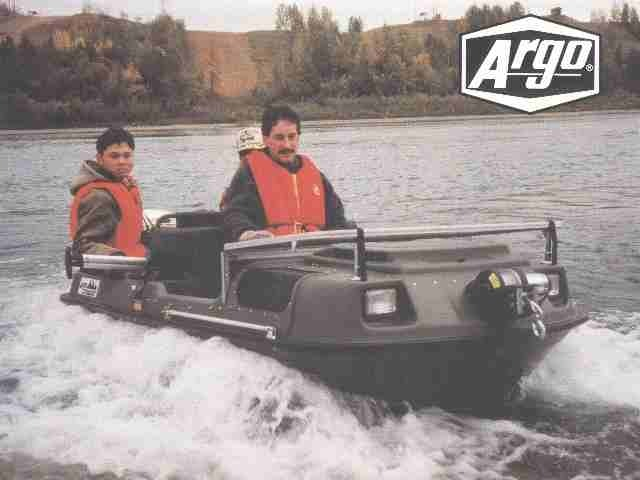

In [22]:
idx_layer, coords = list(topk_activations_by_neuron.items())[0]
coord, topk = list(coords.items())[0]
idx_map, row, col = coord
max_activation, file_idx = topk[0]

image, image_trfm = dataset.get_image(file_idx)
display_image_tensor(image, verbose=True)
probed_neuron = (idx_layer, idx_map, row, col)
idx_layer, idx_map, row, col = probed_neuron

Affichage du champ réceptif du neurone surveillé sélectionné, en prenant en référence l'image après transformation.

In [23]:
batch_input = image_trfm.unsqueeze(dim=0)
output_sizes = get_output_sizes(model_deconv.convnet_features, input_size=batch_input.size())
pixel_space_size = batch_input.size(-2), batch_input.size(-1)
receptive_field = get_receptive_field_in_pixel_space(
    pos=(row, col),
    idx_layer=idx_layer,
    cnn_modules=model_deconv.convnet_features,
    output_sizes=output_sizes,
    pixel_space_size=pixel_space_size
)

((top, left), (bottom, right)) = receptive_field
print("Champ réceptif :", receptive_field, "taille :", right-left+1, "x", bottom-top+1)

Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


Ne pas oublier de redimensioner l'image (avec `image = geo_transforms(image)`) à l'origine de celle de l'entrée pour rendre cohérente la position du champ réception.

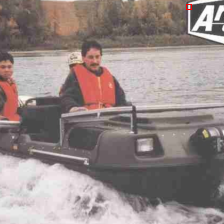

In [24]:
image_resized = geo_transforms(image)
batch_input = batch_input.squeeze(dim=0)
image_resized_receptive_field = T.functional.to_pil_image(image_resized)
img_draw = ImageDraw.Draw(image_resized_receptive_field)
img_draw.rectangle([(left, top), (right, bottom)], outline="red")
display(image_resized_receptive_field)

Déconvolution de l'activation du neurone surveillé sélectionné

In [25]:
output_deconv = deconvolution(
    model_deconv,
    batch_input, # .to(device),
    idx_layer=idx_layer,
    idx_map=idx_map,
    pos=(row, col),
    flip_kernels=False,
    use_bias=False,
    clean_feature_map=True,
    return_pos=False,
    verbose=True
    ).detach().cpu()

[0] forward  Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
	 ouput size: torch.Size([64, 224, 224])
[1] forward  ReLU(inplace=True)
	 ouput size: torch.Size([64, 224, 224])
[2] forward  Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
	 ouput size: torch.Size([64, 224, 224])
[3] forward  ReLU(inplace=True)
	 ouput size: torch.Size([64, 224, 224])
[4] forward  MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
	 ouput size: torch.Size([64, 112, 112])
forwarded output size torch.Size([64, 112, 112]) | switch indices : 1 | min : 0.0 | max : 26.821008682250977
pool_indices.size torch.Size([64, 112, 112])
[4] reverse of  MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
		> output.size :torch.Size([64, 224, 224]) | min : 0.000 | max : 19.214305877685547
[3] reverse of  ReLU(inplace=True)
		> output.size :torch.Size([64, 224, 224]) | min : 0.000 | max : 19.214305877685547
[2] reverse of  Conv2d(64, 64, kerne

Dimensions : torch.Size([3, 224, 224]) 	Valeur min : -20.04645538330078 	Valeur max : 27.810266494750977


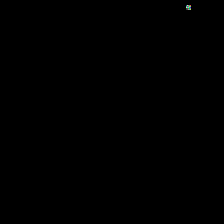

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-20.046455..27.810266].


Dimensions : torch.Size([3, 224, 224]) 	Valeur min : -20.04645538330078 	Valeur max : 27.810266494750977


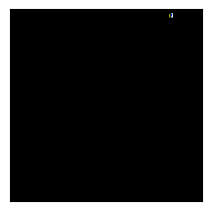

In [26]:
display_image_tensor(output_deconv)
show_image_tensor(output_deconv, figsize=(2, 2))

Dimensions : torch.Size([3, 224, 224]) 	Valeur min : 0.0 	Valeur max : 1.0


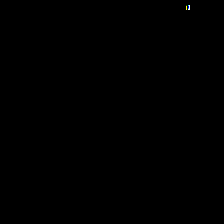

Dimensions : torch.Size([3, 224, 224]) 	Valeur min : 0.0 	Valeur max : 1.0


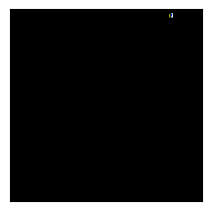

In [27]:
display_image_tensor(output_deconv.clamp(0, 1))
show_image_tensor(output_deconv.clamp(0, 1), figsize=(2, 2))

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : -20.04645538330078 	Valeur max : 27.810266494750977


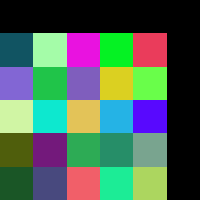

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 1.0


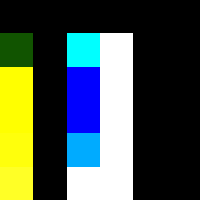

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-20.046455..27.810266].


Dimensions : torch.Size([3, 6, 6]) 	Valeur min : -20.04645538330078 	Valeur max : 27.810266494750977


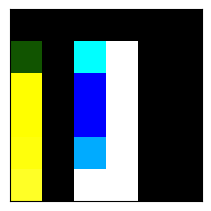

In [28]:
output_deconv_cropped = output_deconv[:, top:bottom+1, left:right+1]
display_image_tensor(output_deconv_cropped, resize=(200, 200))
display_image_tensor(output_deconv_cropped.clamp(0, 1), resize=(200, 200))
show_image_tensor(output_deconv_cropped, verbose=True)

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 27.810266494750977


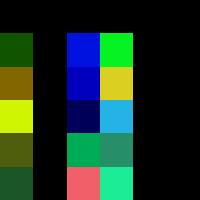

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 1.0


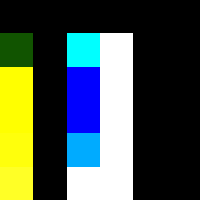

In [29]:
output_deconv_in_pixel_space = torch.nn.functional.relu(output_deconv_cropped)
display_image_tensor(output_deconv_in_pixel_space, resize=(200, 200))
display_image_tensor(output_deconv_in_pixel_space.clamp(0, 1), resize=(200, 200))

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 1.0


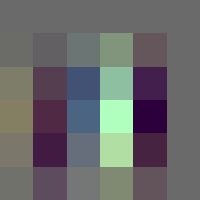

In [30]:
output_deconv_in_pixel_space = to_0_1(output_deconv_cropped)
display_image_tensor(output_deconv_in_pixel_space, resize=(200, 200))

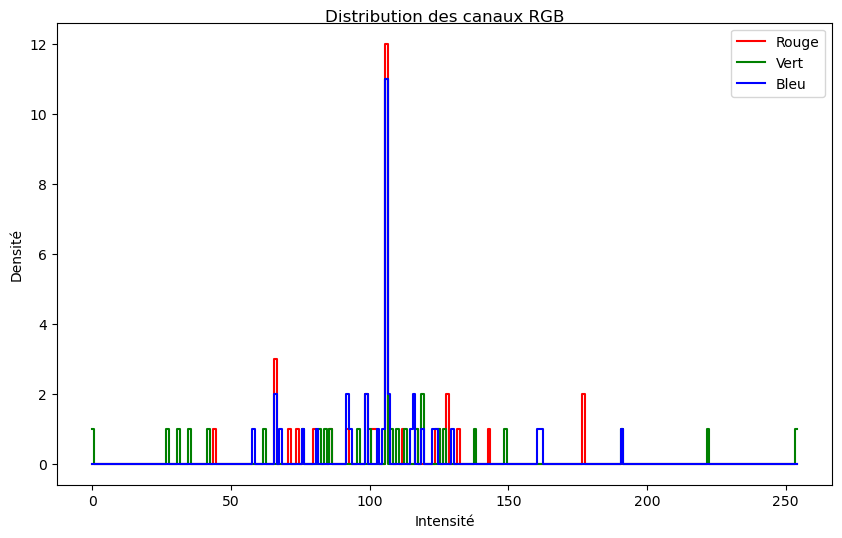

In [31]:
display_rgb_distributions(output_deconv_in_pixel_space.numpy().transpose(1, 2, 0)*255)

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : -4.034405708312988 	Valeur max : 6.685499668121338


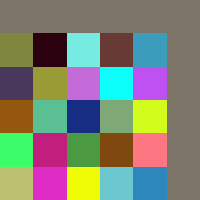

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 1.0


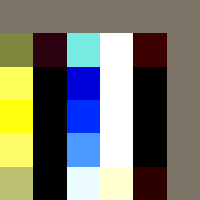

In [32]:
output_deconv_in_pixel_space = inv_normalize(output_deconv_cropped)
display_image_tensor(output_deconv_in_pixel_space, resize=(200, 200))
display_image_tensor(output_deconv_in_pixel_space.clamp(0, 1), resize=(200, 200))

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 1.0


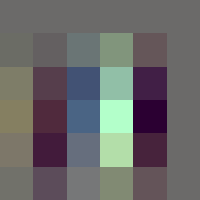

In [33]:
#display_image_tensor(to_0_255(unnormalize(output_deconv, mean=imagenet_mean, std=imagenet_std)), verbose=True)
output_deconv_in_pixel_space = to_0_1(inv_normalize(output_deconv_cropped))
display_image_tensor(output_deconv_in_pixel_space, resize=(200, 200))

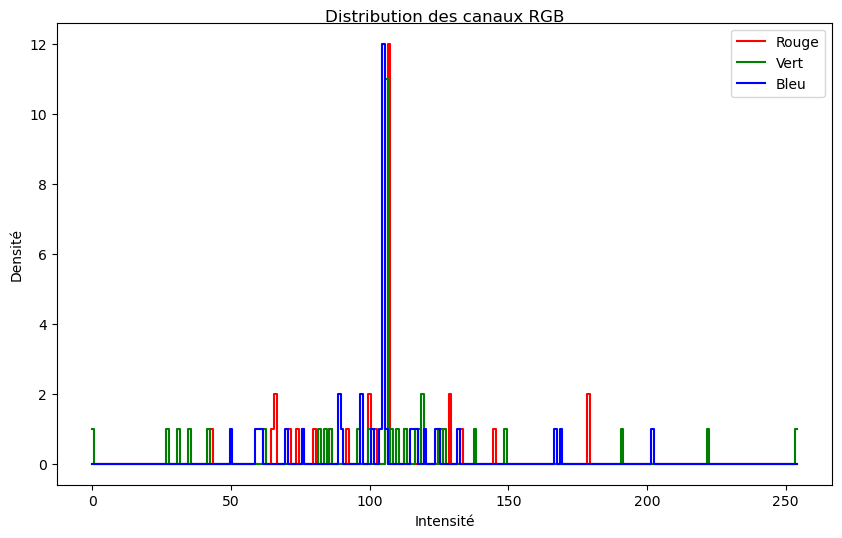

In [34]:
display_rgb_distributions(output_deconv_in_pixel_space.numpy().transpose(1, 2, 0)*255)

Pour le code suivant, on prend l'extrait après les opérations de retour dans l'espace des pixels, pour constater s'il y a une différence. A priori "non" d'après la distribution RGB, mais à confirmer sur une plus grande déconvolution.

Dimensions : torch.Size([3, 6, 6]) 	Valeur min : 0.0 	Valeur max : 1.0


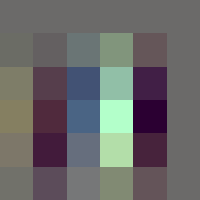

In [35]:
output_deconv
output_deconv_in_pixel_space = to_0_1(inv_normalize(output_deconv))[:, top:bottom+1, left:right+1]
display_image_tensor(output_deconv_in_pixel_space, resize=(200, 200))

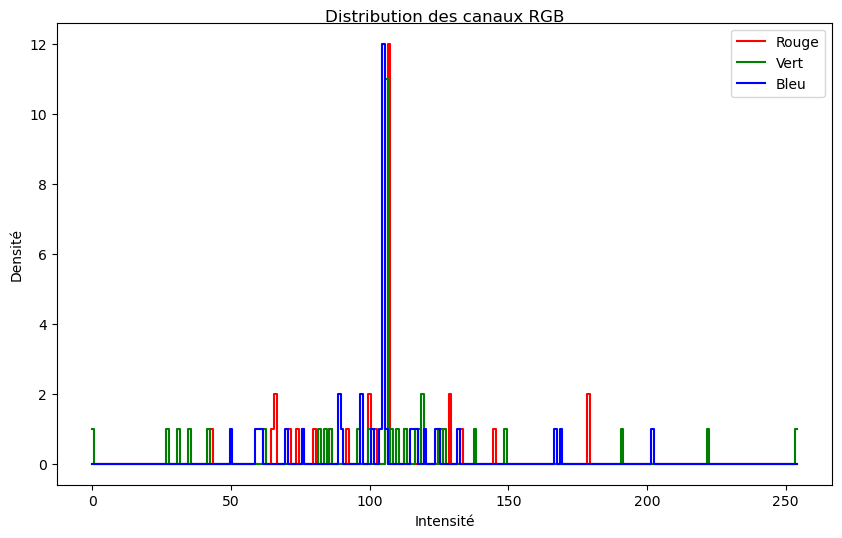

In [36]:
display_rgb_distributions(output_deconv_in_pixel_space.numpy().transpose(1, 2, 0)*255)

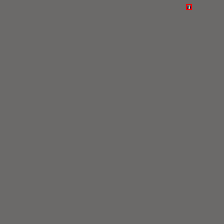

In [37]:
#output_deconv_in_pixel_space = unnormalize(output_deconv, mean=imagenet_mean, std=imagenet_std)
output_deconv_in_pixel_space = to_0_1(inv_normalize(output_deconv))

batch_input = batch_input.squeeze(dim=0)
output_deconv_receptive_field = T.functional.to_pil_image(output_deconv_in_pixel_space)
img_draw = ImageDraw.Draw(output_deconv_receptive_field)
img_draw.rectangle([(left, top), (right, bottom)], outline="red")
display(output_deconv_receptive_field)

Générer les instructions python utilisant les librairies `torch` et `torchvision` pour créer une image par superposition d'une image contenue dans le tenseur output, dont les coordonnées des coins supérieurs gauche et inférieur droit sont données par les coordonnées des coins supérieur gauche et inférieur droit du champ réceptif fournies par (left, top), (right, bottom), et d'une image de fond contenue dans le tenseur image.

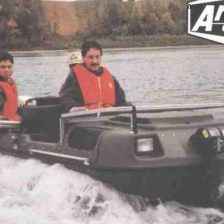

In [38]:
input_and_deconv = merge_input_and_deconv(image_resized, output_deconv_in_pixel_space, receptive_field, alpha=0.95)
display(input_and_deconv)

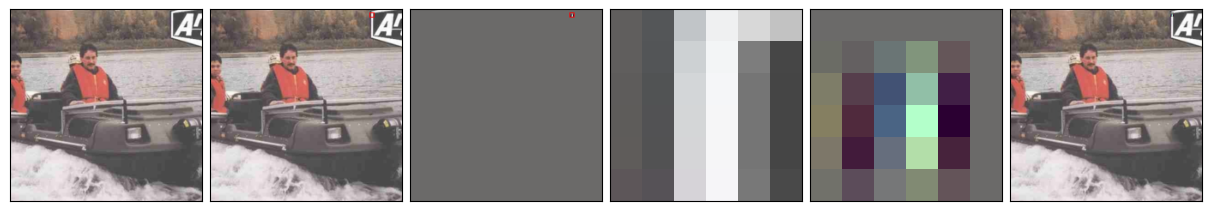

In [39]:
images = [
    image_resized,
    pil_to_tensor(image_resized_receptive_field),
    pil_to_tensor(output_deconv_receptive_field),
    #pil_to_tensor(T.functional.to_pil_image(image_resized).crop((left, top, right, bottom))),
    image_resized[:, top:bottom+1, left:right+1],
    #pil_to_tensor(T.functional.to_pil_image(output_deconv_in_pixel_space).crop((left, top, right, bottom))),
    output_deconv_in_pixel_space[:, top:bottom+1, left:right+1],
    pil_to_tensor(input_and_deconv)
    ]
display_images_list_grid(images, 6)

### Pour l'ensenble des neurones surveillés

Déconvolutions:   0%|          | 0/5 [00:00<?, ?couche/s]

=== Layer 4 neuron (14, 3, 94) ===
	Top value : 19.214303970336914, file_idx : 30916
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


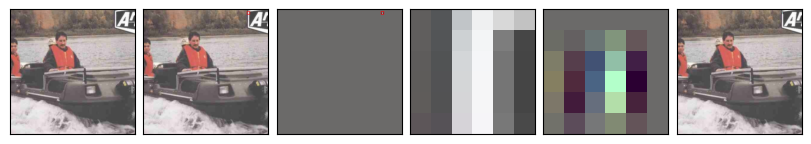

	Top value : 18.79453468322754, file_idx : 44969
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


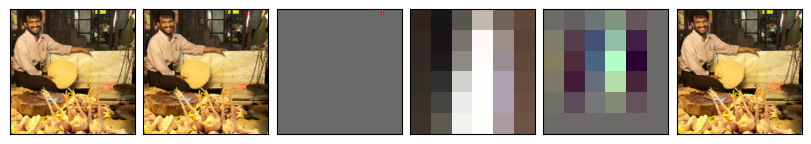

	Top value : 18.69256591796875, file_idx : 20808
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


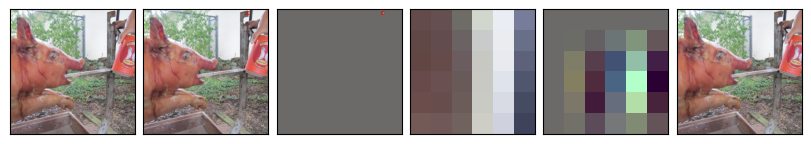

	Top value : 18.23197364807129, file_idx : 22613
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


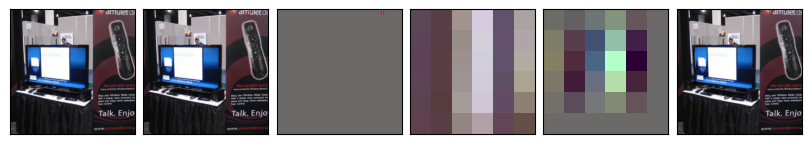

	Top value : 16.6877498626709, file_idx : 32844
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


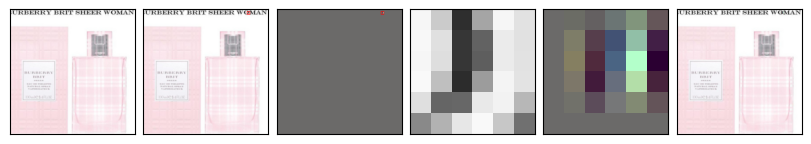

	Top value : 16.53652000427246, file_idx : 15265
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


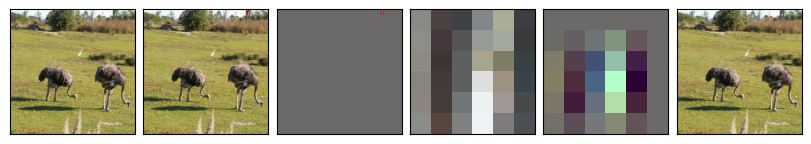

	Top value : 15.719801902770996, file_idx : 7625
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


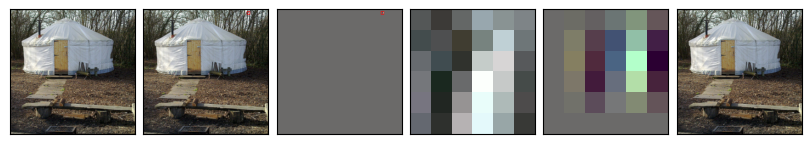

	Top value : 15.552224159240723, file_idx : 36781
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


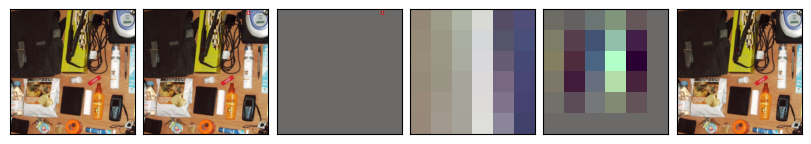

	Top value : 15.523193359375, file_idx : 14286
	Champ réceptif : ((4, 186), (9, 191)) taille : 6 x 6


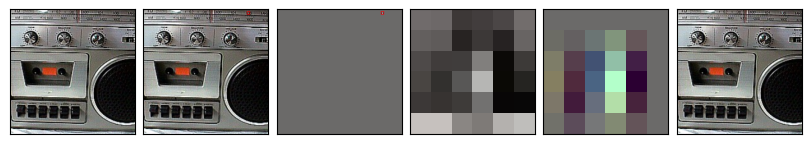

=== Layer 4 neuron (35, 31, 28) ===
	Top value : 22.38262367248535, file_idx : 41837
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


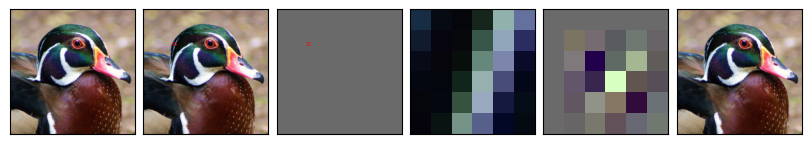

	Top value : 21.833879470825195, file_idx : 46750
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


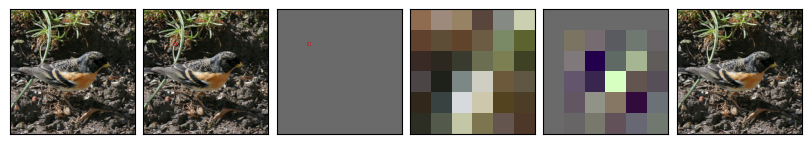

	Top value : 21.737733840942383, file_idx : 45274
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


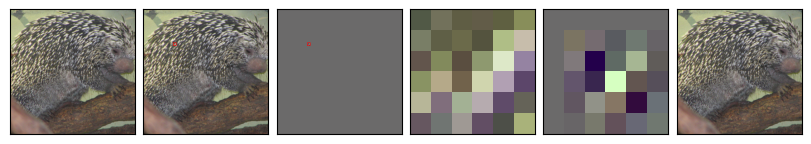

	Top value : 21.543237686157227, file_idx : 16088
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


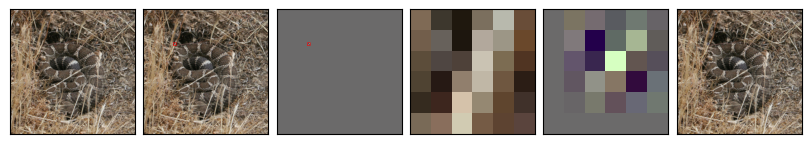

	Top value : 21.454713821411133, file_idx : 3042
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


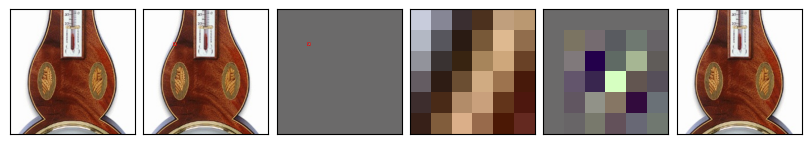

	Top value : 21.026735305786133, file_idx : 31653
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


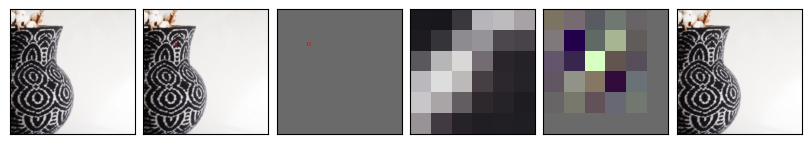

	Top value : 20.972667694091797, file_idx : 18127
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


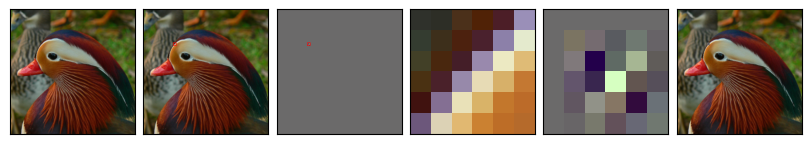

	Top value : 20.88605499267578, file_idx : 5603
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


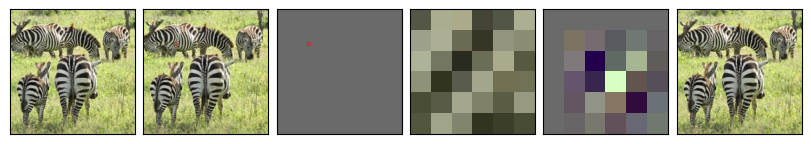

	Top value : 20.685461044311523, file_idx : 8606
	Champ réceptif : ((60, 54), (65, 59)) taille : 6 x 6


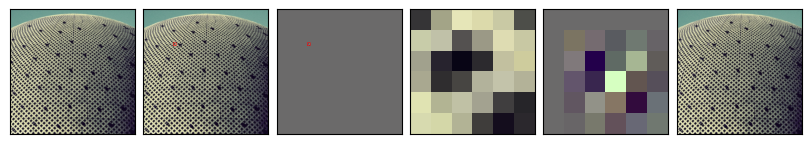

=== Layer 4 neuron (17, 94, 13) ===
	Top value : 9.332990646362305, file_idx : 5853
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


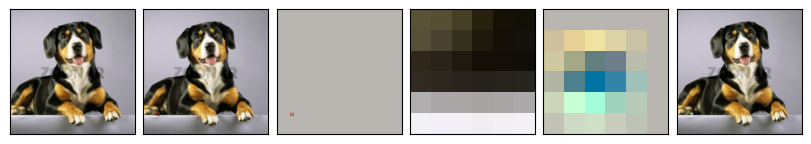

	Top value : 9.218266487121582, file_idx : 20715
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


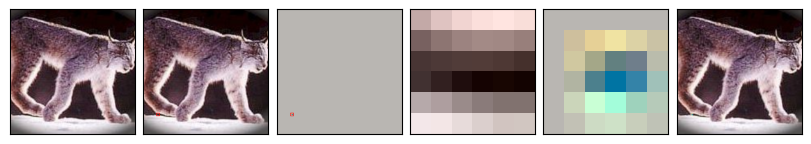

	Top value : 8.940834045410156, file_idx : 28996
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


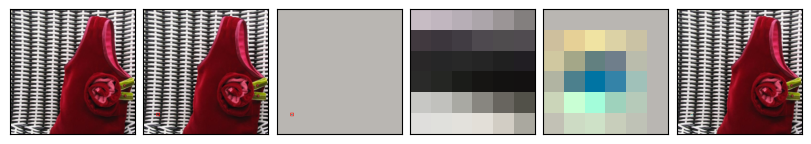

	Top value : 8.680695533752441, file_idx : 13025
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


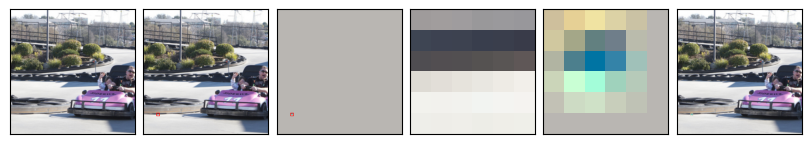

	Top value : 8.65631103515625, file_idx : 49340
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


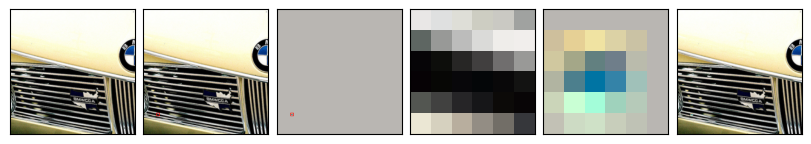

	Top value : 8.498011589050293, file_idx : 1979
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


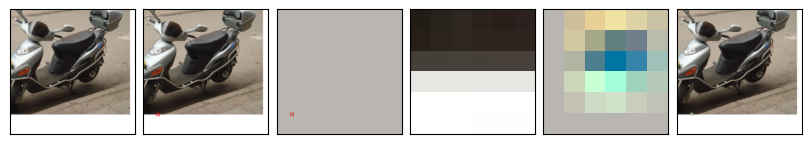

	Top value : 8.451634407043457, file_idx : 45763
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


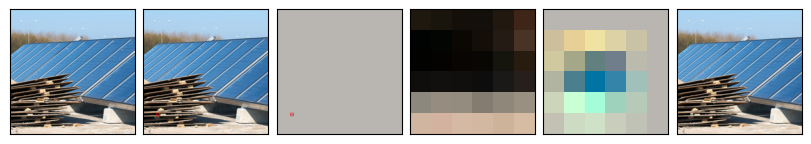

	Top value : 8.38173770904541, file_idx : 38762
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


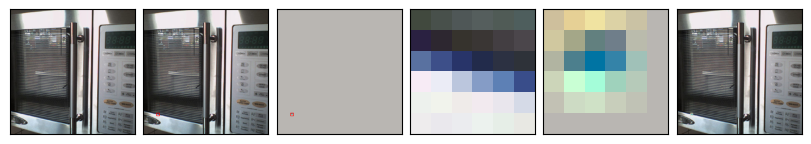

	Top value : 8.37728214263916, file_idx : 44019
	Champ réceptif : ((186, 24), (191, 29)) taille : 6 x 6


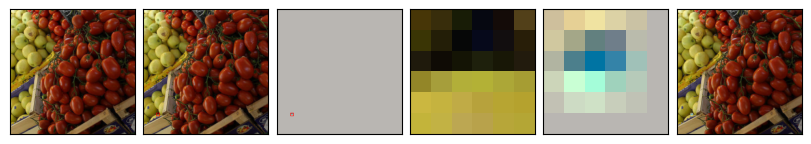

=== Layer 4 neuron (11, 75, 54) ===
	Top value : 24.733844757080078, file_idx : 2530
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


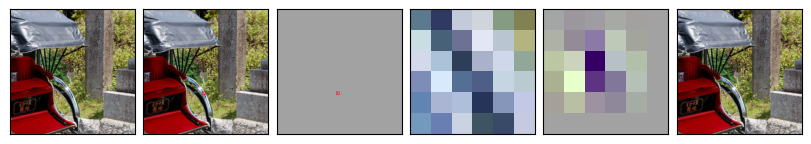

	Top value : 21.50958251953125, file_idx : 38300
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


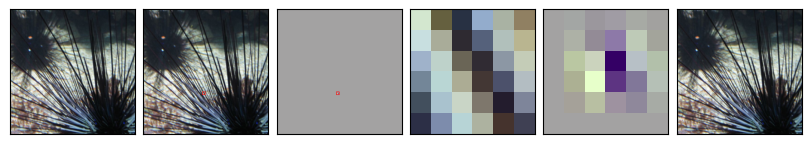

	Top value : 21.335153579711914, file_idx : 41402
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


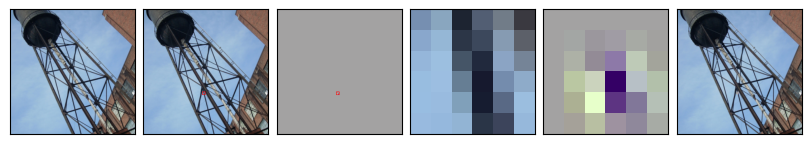

	Top value : 19.439393997192383, file_idx : 30474
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


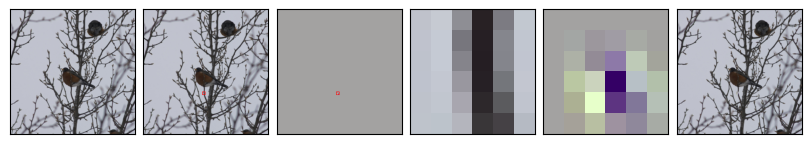

	Top value : 19.028175354003906, file_idx : 22446
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


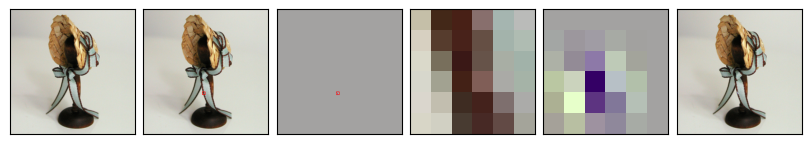

	Top value : 18.88568115234375, file_idx : 22777
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


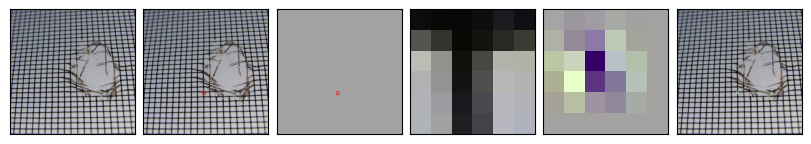

	Top value : 18.77743911743164, file_idx : 15016
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


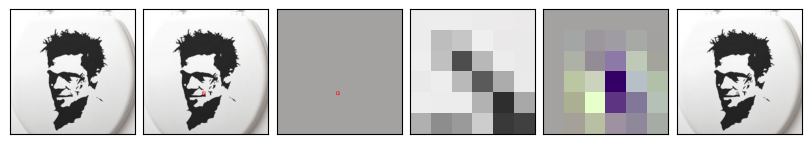

	Top value : 18.629228591918945, file_idx : 18659
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


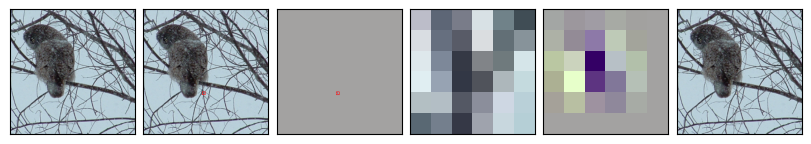

	Top value : 18.39949607849121, file_idx : 23042
	Champ réceptif : ((148, 106), (153, 111)) taille : 6 x 6


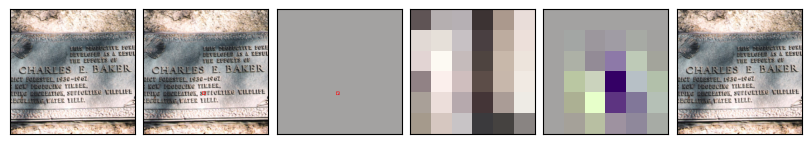

=== Layer 4 neuron (4, 3, 11) ===
	Top value : 24.042924880981445, file_idx : 33185
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


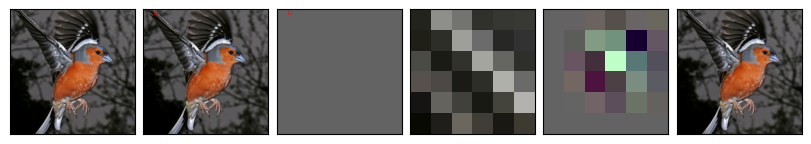

	Top value : 20.725645065307617, file_idx : 4175
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


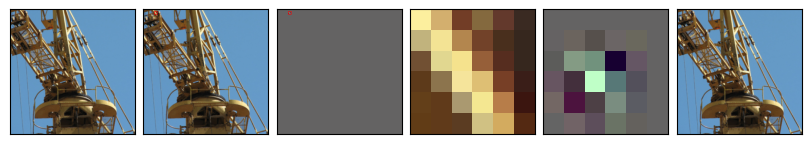

	Top value : 20.201990127563477, file_idx : 2436
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


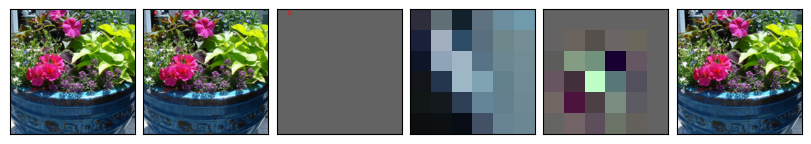

	Top value : 20.118274688720703, file_idx : 25576
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


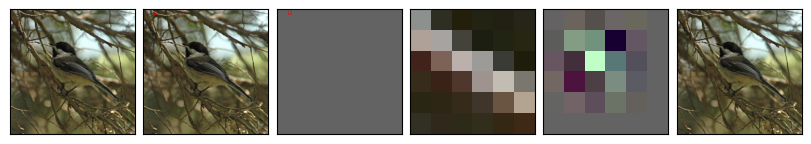

	Top value : 19.655271530151367, file_idx : 18304
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


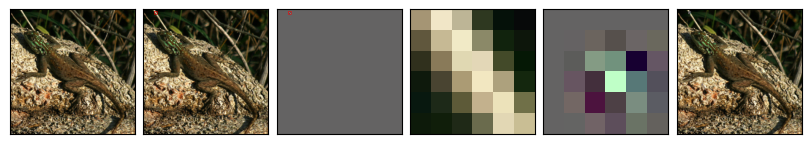

	Top value : 19.321191787719727, file_idx : 1302
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


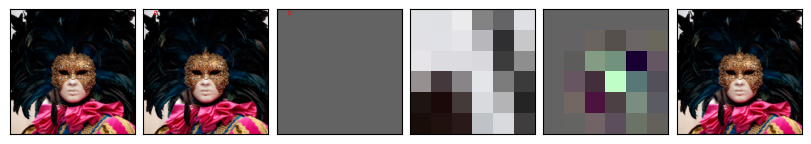

	Top value : 18.50829315185547, file_idx : 25543
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


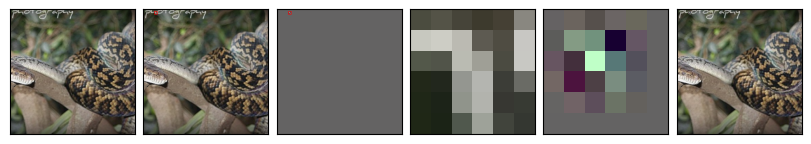

	Top value : 18.051729202270508, file_idx : 13541
	Champ réceptif : ((4, 20), (9, 25)) taille : 6 x 6


In [ ]:
for idx_layer, coords in tqdm(
    topk_activations_by_neuron.items(), total=len(topk_activations_by_neuron), desc="Déconvolutions", unit="couche"
    ):
    for coord, topk in coords.items():
        print(f"=== Layer {idx_layer} neuron {coord} ===")
        idx_map, row, col = coord
        
        for top_value, file_idx in topk:
            print(f"\tTop value : {top_value}, file_idx : {file_idx}")
            image, image_trfm = dataset.get_image(file_idx)
            #display_image_tensor(image, verbose=True)
            probed_neuron = (5, 82, 8, 9)

            # Champ réceptif       
            batch_input = image_trfm.unsqueeze(dim=0)
            output_sizes = get_output_sizes(model_deconv.convnet_features, input_size=batch_input.size())
            pixel_space_size = batch_input.size(-2), batch_input.size(-1)
            receptive_field = get_receptive_field_in_pixel_space(
                pos=(row, col),
                idx_layer=idx_layer,
                cnn_modules=model_deconv.convnet_features,
                output_sizes=output_sizes,
                pixel_space_size=pixel_space_size
            )

            # Drawing the receptive field
            ((top, left), (bottom, right)) = receptive_field
            print("\tChamp réceptif :", receptive_field, "taille :", right-left+1, "x", bottom-top+1)
            image_resized = geo_transforms(image)
            batch_input = batch_input.squeeze(dim=0)
            image_resized_receptive_field = T.functional.to_pil_image(image_resized)
            img_draw = ImageDraw.Draw(image_resized_receptive_field)
            img_draw.rectangle([(left, top), (right, bottom)], outline="red")


            # Déconvolution
            output_deconv = deconvolution(
                model_deconv,
                batch_input, # .to(device),
                idx_layer=idx_layer,
                idx_map=idx_map,
                pos=(row, col),
                flip_kernels=False,
                use_bias=False,
                clean_feature_map=True,
                return_pos=False,
                verbose=False
                ).detach().cpu()
            
            # Transformation to put deconv output in the pixel space
            #output_deconv_in_pixel_space = unnormalize(output_deconv, mean=imagenet_mean, std=imagenet_std)
            output_deconv_in_pixel_space = to_0_1(inv_normalize(output_deconv))
            

            # Drawing the receptive field in the deconv output
            output_deconv_receptive_field = T.functional.to_pil_image(output_deconv_in_pixel_space)
            img_draw = ImageDraw.Draw(output_deconv_receptive_field)
            img_draw.rectangle([(left, top), (right, bottom)], outline="red")

            # Merging
            input_and_deconv = merge_input_and_deconv(
                image_resized, output_deconv_in_pixel_space, receptive_field, alpha=0.95
                )

            # Displaying the images
            images = [
                image_resized,
                pil_to_tensor(image_resized_receptive_field),
                pil_to_tensor(output_deconv_receptive_field),
                #pil_to_tensor(T.functional.to_pil_image(image_resized).crop((left, top, right, bottom))),
                image_resized[:, top:bottom+1, left:right+1],
                #pil_to_tensor(T.functional.to_pil_image(output_deconv_in_pixel_space).crop((left, top, right, bottom))),
                output_deconv_in_pixel_space[:, top:bottom+1, left:right+1],
                pil_to_tensor(input_and_deconv)
                ]
            display_images_list_grid(images, per_rows=6, figsize=(8, 8))